#### Perform the Stationarity of the Time Series using ADF :-----------


### ADF:

1.  ADF stands for Augmented Dickey Fuller Test.

2.  It is a statistical test that is used to determine the stationarity of the time series. (checks whether the time series data is stationary or non-stationary).

3.  It has a p-value

    (a.)    If p-value < 0.05 =============> then the time series is stationary

                                             else  non stationary.


#### Stationarity of the Time Series:----

1.  A time series is said to be in stationary if and only if

    (a.)    Mean remains constant.

    (b.)    Variance remains constant.

    (c.)    Pattern remains constant over the period of time.

    (d.)    Trends remains constant.


2.  A time series is said to be non-stationary if and ony if

    (a.)    Trend follows an upward or downward pattern.

    (b.)    Variance continuously changes over a period of time.


#### Step 1: Import all the necessary libraries

In [329]:
import      numpy                           as      np
import      pandas                          as      pd
import      matplotlib.pyplot               as      plt
import      seaborn                         as      sns

from        statsmodels.tsa.seasonal        import      seasonal_decompose

#### OBSERVATIONS:

1.  pandas =======================>   Creation of dataframe

2.  numpy   ======================>   performing mathematical calculation

3.  matplotlib ===================>  performing data visualizations

4.  seaborn   ====================>  perform data correlation

5.  seasonal_decompose ===========>  used for performing the decomposition on the time series data

#### Step 2: Load the dataset

In [330]:
df = pd.read_csv("AirPassengers.csv")

In [331]:
df.head(10)

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


#### OBSERVATIONS:

1.  The above AirPassengers dataset contains the monthly airline passengers at the starting date of each month beginning from 1949 till 1960.

2.  This dataset is very useful for time series learning.

#### Step 3: Perform Data Exploration

In [332]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [333]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [334]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [335]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [336]:
#### get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### OBSERVATIONS:

1.  The date column is string in nature.

2.  The value is integer in nature.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [337]:
#### Convert the object type of date to datetime

df['date'] = pd.to_datetime(df['date'])

In [338]:
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [339]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [340]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [341]:
#### again get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The date column has been converted from object type to datetime type.

In [342]:
#### Set the date column as an index

df.set_index('date',inplace=True)

In [343]:
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


#### OBSERVATIONS:

1.  The date column has been made as an index.

In [344]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL values in the dataset.

In [345]:
#### Rename the column "value" to "Passengers" in dataset

df.rename(columns={'value':'Passengers'},inplace=True)

In [346]:
df

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passengers' in the dataset.

#### Step 5: Perform the Time series data

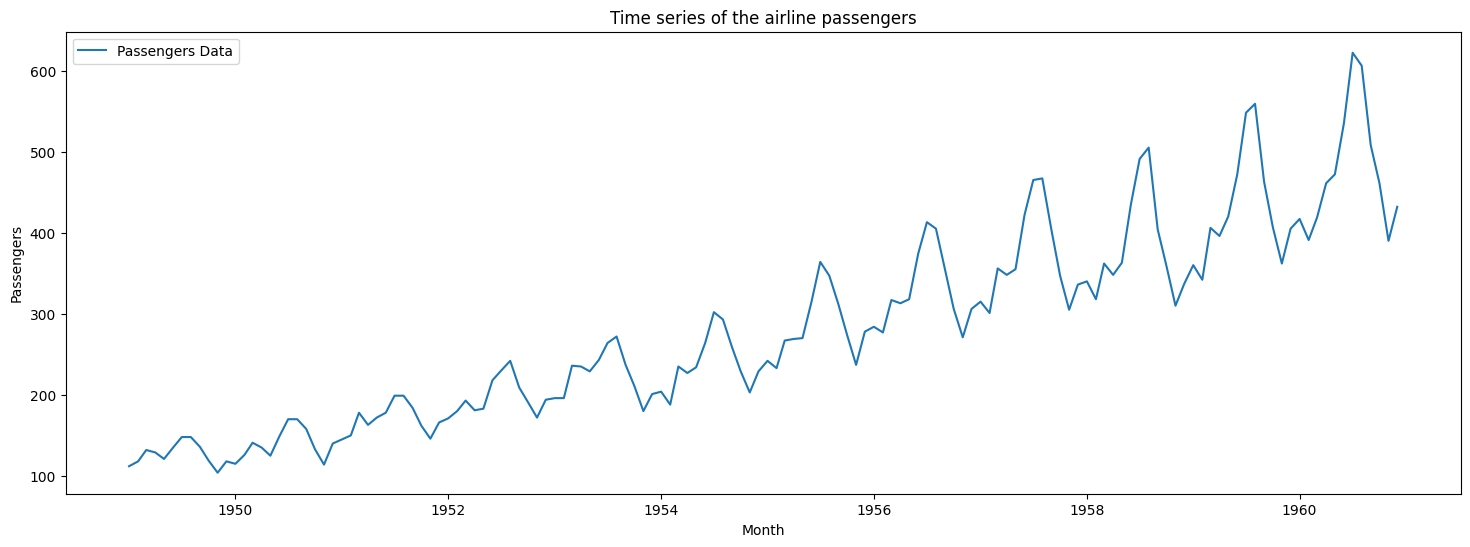

In [347]:
plt.figure(figsize=(18,6))

#### perform the plotting for the monthly passengers data
plt.plot(df.index, df['Passengers'], label = 'Passengers Data')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the monthly passenger data for the starting date of each month beginning from the year 1944 till 1960.

2.  There is an upward trend as shown in the above graph as with the increase in the number of years, the number of airline passengers also increases.

3.  As the trend is continuously moving upwards over a period of time and is not constant, so the time series is considered to be non stationary.

#### Step 6: Check the stationarity of the time series

In [348]:
from    statsmodels.tsa.stattools   import  adfuller

#### perform ADFuller test on Passengers column of the dataset

res = adfuller(df['Passengers'])

print(res)

(np.float64(0.8153688792060482), np.float64(0.991880243437641), 13, 130, {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}, np.float64(996.692930839019))


In [349]:
#### Print the details of adfuller

print('Test Statistics is:', res[0])    ####### measures the stationarity strength

print('P Value is:', res[1])            ####### measures ehether the time series is stationary or not

print('Lag Value is:', res[2])          ####### determines the number of lag observations

print('Number of Observations is:', res[3])  ######### determines the number of total observations

print('Critical values are:')            ####### determines the critical values used

for key,value in res[4].items():
    print(key,":",value)

Test Statistics is: 0.8153688792060482
P Value is: 0.991880243437641
Lag Value is: 13
Number of Observations is: 130
Critical values are:
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


#### OBSERVATIONS:

1.  P Value = 0.99

2.  As the P Value > 0.05 ================> Time series is said to be non stationary time series.

#### CONCLUSIONS:

1.  The above time series data is non stationary in nature.